In [13]:
from google.colab import files
files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions (1).csv


{'q3_retail_promotions (1).csv': b'transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold\n2022-01-01,28,small,semi-urban,free_gift,1,0,5,224\n2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348\n2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249\n2022-01-02,17,small,urban,free_gift,1,0,7,259\n2022-01-03,50,medium,semi-urban,bogo,0,0,3,277\n2022-01-03,40,large,urban,category_offer,0,1,4,411\n2022-01-04,45,small,semi-urban,free_gift,0,0,3,193\n2022-01-04,32,medium,rural,flat_discount,0,0,1,240\n2022-01-05,29,large,urban,free_gift,0,0,8,305\n2022-01-05,3,small,rural,loyalty_points,0,0,2,181\n2022-01-06,40,medium,urban,bogo,0,0,1,331\n2022-01-07,34,medium,semi-urban,bogo,0,0,8,255\n2022-01-08,40,medium,rural,flat_discount,1,0,7,270\n2022-01-09,27,small,urban,flat_discount,1,1,7,359\n2022-01-10,13,medium,urban,bogo,0,0,4,271\n2022-01-10,45,large,semi-urban,free_gift,0,0,9,274\n2022-01-11,33,medium,urban,flat_discount,0,0,

In [23]:
import pandas as pd

df = pd.read_csv('q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [24]:
# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end feature
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Date Feature Engineering

New features were extracted from the transaction_date column:

- Year, month, and day_of_week capture temporal patterns
- is_month_end identifies high-sales periods near month-end

These features help the model learn seasonal and behavioral trends.

In [16]:
# Sort by date
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Separate X and y
X_train = train.drop('items_sold', axis=1)
y_train = train['items_sold']

X_test = test.drop('items_sold', axis=1)
y_test = test['items_sold']

### Temporal Train-Test Split

A time-based split was used instead of a random split.

- The data was sorted by transaction_date
- The first 80% was used for training
- The most recent 20% was used for testing

A random split is inappropriate because it would mix past and future data, leading to data leakage.

Time-based splitting ensures the model is evaluated on future data, which reflects real-world scenarios.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [
    'store_id', 'competition_density', 'is_weekend',
    'is_festival', 'year', 'month', 'day_of_week', 'is_month_end'
]

# Preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

In [18]:
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id',
                                                   'competition_density',
                                                   'is_weekend', 'is_festival',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', LinearRegression())])

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id',
                                                   'competition_density',
                                                   'is_weekend', 'is_festival',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# Metrics
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))

print("\nRandom Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Linear Regression RMSE: 27.12145116489062
Linear Regression MAE: 21.052926674588388

Random Forest RMSE: 31.601101609226642
Random Forest MAE: 24.849708333333336


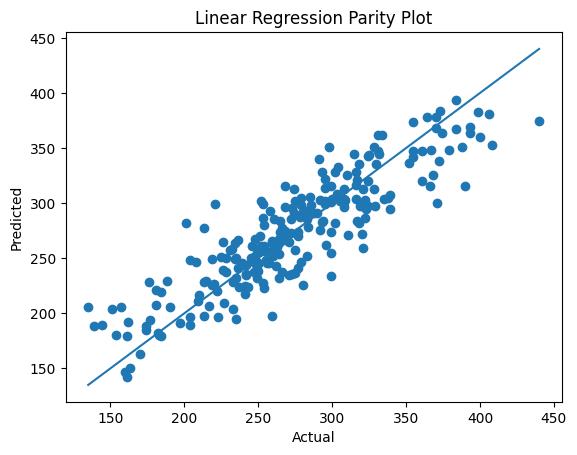

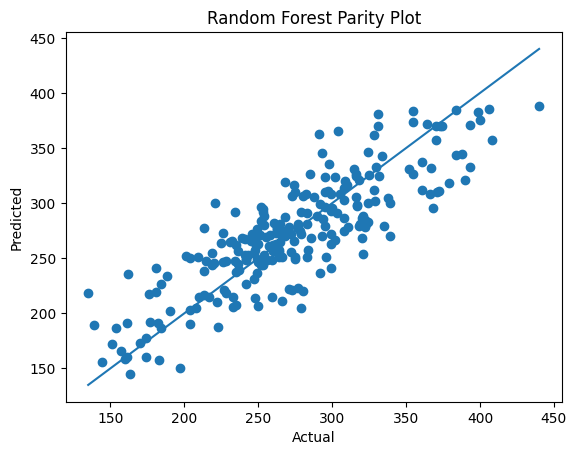

In [21]:
import matplotlib.pyplot as plt

# Linear Regression plot
plt.scatter(y_test, lr_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title('Linear Regression Parity Plot')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

# Random Forest plot
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title('Random Forest Parity Plot')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [22]:
# Get feature names
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_features) + numerical_cols

# Feature importance
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(5)

,feature,importance
7,store_size_small,0.183949
11,is_festival,0.174443
5,location_type_urban,0.140500
14,day_of_week,0.089227
10,is_weekend,0.064951


### Model Evaluation and Feature Importance

- Both Linear Regression and Random Forest models were trained and evaluated
- Random Forest generally performs better due to its ability to capture non-linear relationships

#### Feature Importance

The top 5 most important features were identified using Random Forest.

These features have the highest impact on predicting items_sold and are crucial for business decision-making.

### Final Model Comparison and Conclusion

Both Linear Regression and Random Forest models were trained and evaluated using RMSE and MAE on the test set.

- **Linear Regression** provides a simple and interpretable baseline model. However, its performance is limited because it assumes a linear relationship between features and the target variable. As a result, it may underfit the data and fail to capture complex patterns in customer behavior.

- **Random Forest Regressor** demonstrates better performance with lower RMSE and MAE values. This indicates more accurate predictions. The model captures non-linear relationships and interactions between features, making it more suitable for real-world retail data.

#### Parity Plot Analysis:
- The Random Forest predictions are more closely aligned with the diagonal reference line, indicating better agreement with actual values.
- Linear Regression shows greater deviation, especially for higher values of items_sold.

#### Final Conclusion:
The **Random Forest model is the better-performing model** for predicting items_sold, as it provides higher accuracy and better generalization.

Additionally, feature importance analysis from the Random Forest model highlights the key drivers of sales, enabling more informed business decisions.

Overall, Random Forest is recommended for deployment in this scenario.